# RoomBeacon — Nearby Rental Search & Spatial Discovery Prototype

This notebook implements the **product-validation and spatial retrieval layer** of RoomBeacon.

While Notebook 04 answers:
> *"Can RoomBeacon accurately estimate rental price?"*

Notebook 05 answers:
> *"Can RoomBeacon help a user find trustworthy rental listings near a location they care about?"*

### Core Architectural Invariants:
1. **Consumes Canonical Silver Parquet directly** without mutating Silver or depending on raw Bronze.
2. **Never fakes numeric distance:** True geographic distance (`distance_km`) is strictly calculated via vectorized Haversine *only* when both the reference point and the listing have validated, trusted coordinates.
3. **Rigorous 5-State Location Taxonomy:** Strictly separates capability from search results and true unresolved listings from out-of-area listings:
   - `EXACT_DISTANCE_CAPABLE`: Trusted coordinate available for geographic distance.
   - `SAME_WARD`: Untrusted coordinate, matching reference ward (distance strictly null).
   - `SAME_DISTRICT`: Untrusted coordinate, matching reference district (distance strictly null).
   - `RESOLVED_OUTSIDE_REFERENCE_AREA`: Usable administrative location in other wards/districts (not unresolved!).
   - `LOCATION_UNRESOLVED`: Truly unresolvable (no coordinate, no ward, no district).
4. **Explicit Reference Location Contract:** Distinguishes verified vs `USER_SUPPLIED_UNVERIFIED` context without fabricating reverse-geocoding network calls.
5. **Coordinate Search Quality & Deterministic Ranking:** Evaluates `coordinate_search_status` (`TRUSTED_CONSISTENT`, `TRUSTED_ADMIN_UNVERIFIED`, `TRUSTED_BUT_ADMIN_MISMATCH`, `SHARED_POINT_CONFLICT`) to prevent pin-error listings (e.g. ID 69388) from ranking equally with genuine local listings.
6. **Configurable Price Display Policy:** Defaults to `TRUSTED_ONLY` to prevent unverified prices from entering product validation.

## 1. Environment Setup & Helper Imports

In [1]:
from pathlib import Path
import sys
PROJECT_ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / 'crawler').is_dir() and (p / 'analytics').is_dir())
sys.path.insert(0, str(PROJECT_ROOT))

import json
from datetime import datetime, timezone
import numpy as np
import pandas as pd
import duckdb
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, Markdown

from analytics.duckdb.connection import resolve_runtime_path
from roombeacon_crawler.config.get_env import env
from notebooks.utils.nearby_rental_search import (
    is_valid_coordinate,
    haversine_distance_km,
    assign_distance_band,
    filter_rental_compatible,
    derive_display_price,
    create_reference_location_contract,
    classify_coordinate_search_status,
    format_filter_range,
    audit_location_coverage,
    execute_nearby_rental_search,
    build_search_funnel,
    summarize_radius_market,
    evaluate_product_readiness,
)

pd.set_option('display.max_columns', 30)
pd.set_option('display.float_format', lambda x: f'{x:,.2f}' if abs(x) < 1000 else f'{x:,.0f}')
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
display(Markdown('**Environment and nearby search helpers initialized successfully.**'))

**Environment and nearby search helpers initialized successfully.**

## 2. Search Configuration

Configure the reference search point, price display policy, and optional filters.

- **Mode A (Exact Coordinate):** User or client provides latitude and longitude.
- **Mode B (Administrative Context):** Optional reference ward and district for fallback retrieval when coordinates are missing or untrusted.
- **Price Display Policy:** Defaults to `TRUSTED_ONLY` (only `TRUSTED_EXISTING` and `TRUSTED_REPARSED` targets are shown).


In [2]:
# ==============================================================================
# SEARCH CONFIGURATION (Easily configurable by user / application client)
# ==============================================================================
REFERENCE_NAME = "Đại học Bách Khoa TP.HCM (Campus Lý Thường Kiệt, Q.10)"
REFERENCE_LATITUDE = 10.7725
REFERENCE_LONGITUDE = 106.6578

# Administrative fallback configuration
REFERENCE_WARD = "Phường Tân Bình"  # Ward containing / adjacent to campus in Silver mapping
REFERENCE_DISTRICT = "Quận 10"

# Retrieval thresholds & optional filters
SEARCH_RADIUS_KM = 3.0
MAX_RESULTS = 20

# Product price display policy: "TRUSTED_ONLY" or "ALLOW_REVIEW_WITH_WARNING"
PRICE_DISPLAY_POLICY = "TRUSTED_ONLY"

# Optional rental filters (set to None to disable)
MIN_PRICE = None
MAX_PRICE = 10_000_000.0  # Optional filter: <= 10 triệu/tháng
MIN_AREA = 15.0           # Optional filter: >= 15 m²
MAX_AREA = None

config_summary = pd.DataFrame([
    {"Parameter": "Reference Location Name", "Value": REFERENCE_NAME},
    {"Parameter": "Reference Coordinates", "Value": f"({REFERENCE_LATITUDE:.4f}, {REFERENCE_LONGITUDE:.4f})"},
    {"Parameter": "Reference Ward", "Value": REFERENCE_WARD or "None"},
    {"Parameter": "Reference District", "Value": REFERENCE_DISTRICT or "None"},
    {"Parameter": "Search Radius", "Value": f"{SEARCH_RADIUS_KM:.1f} km"},
    {"Parameter": "Max Display Results", "Value": str(MAX_RESULTS)},
    {"Parameter": "Price Display Policy", "Value": PRICE_DISPLAY_POLICY},
    {"Parameter": "Price Filter (Min - Max)", "Value": format_filter_range(MIN_PRICE, MAX_PRICE, "VNĐ")},
    {"Parameter": "Area Filter (Min - Max)", "Value": format_filter_range(MIN_AREA, MAX_AREA, "m²")},
])
display(config_summary)

,Parameter,Value
0,Reference Location Name,Đại học Bách Khoa TP.HCM (Campus Lý Thường Kiệ...
1,Reference Coordinates,"(10.7725, 106.6578)"
2,Reference Ward,Phường Tân Bình
3,Reference District,Quận 10
4,Search Radius,3.0 km
5,Max Display Results,20
6,Price Display Policy,TRUSTED_ONLY
7,Price Filter (Min - Max),"None - 10,000,000 VNĐ"
8,Area Filter (Min - Max),15 - Unlimited m²


## 3. Load Canonical Silver Parquet

In [3]:
SILVER_PATH = resolve_runtime_path(env.processing.silver_dir) / 'rental_listings.parquet'
assert SILVER_PATH.exists(), f'Canonical Silver not found at {SILVER_PATH}'

with duckdb.connect(':memory:') as con:
    silver_df = con.execute('SELECT * FROM read_parquet(?)', [str(SILVER_PATH)]).df()

# Dynamic invariant assertions (no hardcoded row count)
assert len(silver_df) > 0, 'Canonical Silver dataset is empty'
assert 'rental_post_id' in silver_df.columns, 'rental_post_id column missing from Silver'
assert silver_df['rental_post_id'].notna().all(), 'rental_post_id contains nulls'
assert silver_df['rental_post_id'].is_unique, 'rental_post_id must be strictly unique'

# Optional dynamic metadata validation
meta_path = SILVER_PATH.parent / 'silver_metadata.json'
if meta_path.exists():
    with open(meta_path, 'r', encoding='utf-8') as f:
        meta = json.load(f)
        if 'row_count' in meta:
            assert len(silver_df) == meta['row_count'], f"Parquet row count ({len(silver_df)}) does not match metadata ({meta['row_count']})"

display(pd.DataFrame([{
    'Silver Parquet Path': str(SILVER_PATH),
    'Total Rows': f'{len(silver_df):,}',
    'Total Columns': len(silver_df.columns),
    'Unique Listings': f'{silver_df.rental_post_id.nunique():,}',
}]))

,Silver Parquet Path,Total Rows,Total Columns,Unique Listings
0,/data/projects/roombeacon/source/roombeacon-sy...,"132,436",71,"132,436"


## 4. Rental Search Population Eligibility & Price Policy

Filter Silver listings to the **ordinary rental-compatible population**:
- Excludes explicit `SALE` and `TRANSFER` intent.
- Excludes aggregate building operations (`WHOLE_BUILDING`, `MULTI_UNIT_BUSINESS`).
- Retains `UNKNOWN` semantics absent conflicting evidence.
- Applies `PRICE_DISPLAY_POLICY = "TRUSTED_ONLY"`: Only verified target prices (`TRUSTED_EXISTING`, `TRUSTED_REPARSED`) are exposed.


In [4]:
rental_df = filter_rental_compatible(silver_df)
rental_df = derive_display_price(rental_df, price_display_policy=PRICE_DISPLAY_POLICY)

compat_summary = pd.DataFrame([
    {"Population Stage": "Total Canonical Silver", "Rows": len(silver_df), "Percent of Silver": 100.0},
    {"Population Stage": "Rental-compatible Search Population", "Rows": len(rental_df), "Percent of Silver": round(len(rental_df) / len(silver_df) * 100, 2)},
    {"Population Stage": "Excluded (SALE / TRANSFER / WHOLE_BUILDING)", "Rows": len(silver_df) - len(rental_df), "Percent of Silver": round((len(silver_df) - len(rental_df)) / len(silver_df) * 100, 2)},
])
display(compat_summary)

price_policy_dist = rental_df['price_display_status'].value_counts().reset_index()
price_policy_dist.columns = ['Price Display Status', 'Listing Count']
price_policy_dist['Share %'] = (price_policy_dist['Listing Count'] / len(rental_df) * 100).round(2)
display(price_policy_dist)

,Population Stage,Rows,Percent of Silver
0,Total Canonical Silver,132436,100.00
1,Rental-compatible Search Population,131941,99.63
2,Excluded (SALE / TRANSFER / WHOLE_BUILDING),495,0.37


,Price Display Status,Listing Count,Share %
0,TRUSTED,118672,89.94
1,REVIEW_EXCLUDED,8036,6.09
2,MISSING,3817,2.89
3,SUSPECT_UNIT_SCALE,1416,1.07


## 5. Location Quality & Coordinate Coverage Audit

Before performing spatial retrieval, we measure the empirical location quality across the rental population.
This answers the critical question:
> **"How much of RoomBeacon can actually support true radius search today?"**


In [5]:
coverage_audit = audit_location_coverage(rental_df)
display(coverage_audit)

display(Markdown('''
> **Key Finding on Coordinate Coverage:**
> - Only **~1.72%** (2,268 listings) possess validated, trusted coordinates (`has_trusted_coordinate == True`).
> - **7.98%** (10,533 listings) have coordinates that represent **shared portal hotspots / district defaults** with conflicting street addresses. These cannot be trusted for exact distance.
> - In contrast, **83.74%** (110,481 listings) have resolved administrative wards (`ward_current`).
> - Therefore, RoomBeacon currently operates as an **administrative-location retrieval system with a high-precision radius search tier**.
'''))

,Metric,Count,Percent
0,Total rental-compatible listings,131941,100.00
1,Coordinate fields present (lat & lon),12801,9.70
2,"Valid coordinate pairs (-90..90, -180..180, no...",12801,9.70
3,Trusted coordinate pairs (exact-distance capable),2268,1.72
4,Suspicious shared/default coordinates (conflic...,10533,7.98
5,Missing coordinate pairs,119140,90.30
6,Administrative ward resolved (ward_current),110481,83.74
7,Administrative district resolved,50781,38.49
8,"Unresolved location (no trusted coord, no ward...",15978,12.11



> **Key Finding on Coordinate Coverage:**
> - Only **~1.72%** (2,268 listings) possess validated, trusted coordinates (`has_trusted_coordinate == True`).
> - **7.98%** (10,533 listings) have coordinates that represent **shared portal hotspots / district defaults** with conflicting street addresses. These cannot be trusted for exact distance.
> - In contrast, **83.74%** (110,481 listings) have resolved administrative wards (`ward_current`).
> - Therefore, RoomBeacon currently operates as an **administrative-location retrieval system with a high-precision radius search tier**.


## 6. Reference Location Contract Validation

In [6]:
ref_contract = create_reference_location_contract(
    name=REFERENCE_NAME,
    latitude=REFERENCE_LATITUDE,
    longitude=REFERENCE_LONGITUDE,
    ward=REFERENCE_WARD,
    district=REFERENCE_DISTRICT,
)

ref_info = pd.DataFrame([{
    'Reference Name': ref_contract['reference_name'],
    'Latitude': ref_contract['reference_latitude'],
    'Longitude': ref_contract['reference_longitude'],
    'Admin Verification Status': ref_contract['reference_admin_verification_status'],
    'Exact Distance Capable': ref_contract['is_exact_distance_capable'],
    'Fallback Ward': ref_contract['reference_ward'],
    'Fallback District': ref_contract['reference_district'],
}])
display(ref_info)

display(Markdown(f'''
> **Reference Location Verification Status:** `{ref_contract['reference_admin_verification_status']}`
> Coordinates and administrative labels are user-configured. Because offline polygon GIS boundaries are not embedded in the repository, administrative labels remain marked `USER_SUPPLIED_UNVERIFIED` rather than assuming external GIS verification.
'''))

,Reference Name,Latitude,Longitude,Admin Verification Status,Exact Distance Capable,Fallback Ward,Fallback District
0,Đại học Bách Khoa TP.HCM (Campus Lý Thường Kiệ...,10.77,106.66,USER_SUPPLIED_UNVERIFIED,True,Phường Tân Bình,Quận 10



> **Reference Location Verification Status:** `USER_SUPPLIED_UNVERIFIED`
> Coordinates and administrative labels are user-configured. Because offline polygon GIS boundaries are not embedded in the repository, administrative labels remain marked `USER_SUPPLIED_UNVERIFIED` rather than assuming external GIS verification.


## 7. Multi-Tier Nearby Rental Retrieval & Location Taxonomy

We execute the multi-tier retrieval engine:
1. **Exact Distance Capable (Tier 1):** Vectorized Haversine distance computed exclusively on trusted coordinates. Listings filtered to $\le$ `SEARCH_RADIUS_KM` and sorted by deterministic priority:
   `TRUSTED_CONSISTENT` $\rightarrow$ `TRUSTED_ADMIN_UNVERIFIED` $\rightarrow$ `TRUSTED_BUT_ADMIN_MISMATCH`, then `distance_km` ascending.
2. **Same Ward Fallback (Tier 2):** Listings in the reference ward whose coordinates are untrusted/missing. Distance is strictly null.
3. **Same District Fallback (Tier 3):** Listings in the reference district outside the reference ward. Distance is strictly null.
4. **Resolved Outside Reference Area (Tier 4):** Usable administrative location in another ward/district (not unresolved!).
5. **Location Unresolved (Tier 5):** Truly unresolvable listings (no coordinates, no ward, no district).


In [7]:
exact_results, same_ward_results, same_district_results, search_df = execute_nearby_rental_search(
    rental_df,
    reference_latitude=REFERENCE_LATITUDE,
    reference_longitude=REFERENCE_LONGITUDE,
    reference_ward=REFERENCE_WARD,
    reference_district=REFERENCE_DISTRICT,
    radius_km=SEARCH_RADIUS_KM,
    min_price=MIN_PRICE,
    max_price=MAX_PRICE,
    min_area=MIN_AREA,
    max_area=MAX_AREA,
    max_results=MAX_RESULTS,
    price_display_policy=PRICE_DISPLAY_POLICY,
)

# 1. 5-State Search Location Taxonomy Distribution
taxonomy_counts = search_df['location_match_type'].value_counts().reset_index()
taxonomy_counts.columns = ['Search Location Taxonomy State', 'Listing Count']
taxonomy_counts['Share %'] = (taxonomy_counts['Listing Count'] / len(search_df) * 100).round(2)
display(Markdown('### Search Location Taxonomy (Mutually Exclusive Partition)'))
display(taxonomy_counts)

# 2. Coordinate Search Quality Distribution
coord_quality = search_df['coordinate_search_status'].value_counts().reset_index()
coord_quality.columns = ['Coordinate Search Quality Status', 'Listing Count']
coord_quality['Share %'] = (coord_quality['Listing Count'] / len(search_df) * 100).round(2)
display(Markdown('### Overall Coordinate Search Quality Status'))
display(coord_quality)

### Search Location Taxonomy (Mutually Exclusive Partition)

,Search Location Taxonomy State,Listing Count,Share %
0,RESOLVED_OUTSIDE_REFERENCE_AREA,101230,76.72
1,LOCATION_UNRESOLVED,15978,12.11
2,SAME_WARD,9083,6.88
3,SAME_DISTRICT,3382,2.56
4,EXACT_DISTANCE_CAPABLE,2268,1.72


### Overall Coordinate Search Quality Status

,Coordinate Search Quality Status,Listing Count,Share %
0,MISSING,119140,90.30
1,SHARED_POINT_CONFLICT,10533,7.98
2,TRUSTED_ADMIN_UNVERIFIED,1041,0.79
3,TRUSTED_BUT_ADMIN_MISMATCH,997,0.76
4,TRUSTED_CONSISTENT,230,0.17


## 8. Search Coverage Funnel

Conversion funnel from the total rental-compatible population down to concentric distance bands, coordinate quality, and administrative fallbacks.


In [8]:
funnel_df = build_search_funnel(search_df, radius_km=SEARCH_RADIUS_KM)
display(funnel_df)

,Category,Stage,Count,Share % (Total),Share % (Exact)
0,Total Population,1. Rental-compatible listings,131941,100.00,100.00
1,Search Taxonomy (Mutually Exclusive),├── Exact-distance capable (trusted coords),2268,1.72,100.00
2,Search Taxonomy (Mutually Exclusive),├── Fallback: Same Ward matches,9083,6.88,0.00
3,Search Taxonomy (Mutually Exclusive),├── Fallback: Same District matches,3382,2.56,0.00
4,Search Taxonomy (Mutually Exclusive),├── Resolved outside reference area,101230,76.72,0.00
5,Search Taxonomy (Mutually Exclusive),"└── Location unresolved (no coords, no admin)",15978,12.11,0.00
6,Exact Radius Reach,2. Exact distance <= 10 km,1877,1.42,82.76
7,Exact Radius Reach,3. Exact distance <= 5 km,839,0.64,36.99
8,Exact Radius Reach,4. Exact distance <= 3 km,290,0.22,12.79
9,Exact Radius Reach,5. Exact distance <= 1 km,32,0.02,1.41


## 9. Ranked Search Results Presentation

In [9]:
cols_to_show = [
    'rental_post_id', 'source_code', 'title_clean', 'display_price',
    'price_display_status', 'area_value_clean', 'ward_current',
    'district_text_extracted', 'coordinate_search_status', 'distance_km',
    'distance_band', 'location_match_type', 'latest_observed_at',
]

display(Markdown(f'### Top Exact-Distance Results within {SEARCH_RADIUS_KM:.1f} km (Ranked by Coordinate Quality & Distance)'))
if len(exact_results) > 0:
    display(exact_results[cols_to_show].head(MAX_RESULTS))
else:
    display(Markdown('*No exact-distance listings matched the criteria within this radius.*'))

display(Markdown(f'### Administrative Fallback: Same Ward ({REFERENCE_WARD}) — Distance Unavailable'))
if len(same_ward_results) > 0:
    display(same_ward_results[cols_to_show].head(10))
else:
    display(Markdown('*No same-ward fallback listings available.*'))

display(Markdown(f'### Administrative Fallback: Same District ({REFERENCE_DISTRICT}) — Distance Unavailable'))
if len(same_district_results) > 0:
    display(same_district_results[cols_to_show].head(10))
else:
    display(Markdown('*No same-district fallback listings available.*'))

### Top Exact-Distance Results within 3.0 km (Ranked by Coordinate Quality & Distance)

,rental_post_id,source_code,title_clean,display_price,price_display_status,area_value_clean,ward_current,district_text_extracted,coordinate_search_status,distance_km,distance_band,location_match_type,latest_observed_at
24116,84749,mogi,"phòng trọ q10, giờ tự do, khoá vân tay, tầng trệt","4,000,000",TRUSTED,20.00,Phường Tân Bình,Quận 10,TRUSTED_CONSISTENT,0.22,<= 1 km,EXACT_DISTANCE_CAPABLE,2026-09-22 08:21:42
41391,105477,mogi,Cho thuê duplex cửa sổ không giới hạn người ở ...,"5,000,000",TRUSTED,25.00,Phường Tân Bình,Quận 10,TRUSTED_CONSISTENT,0.49,<= 1 km,EXACT_DISTANCE_CAPABLE,2026-09-23 09:58:49
12131,70894,mogi,Cho thuê phòng tách bếp Full nội thất ở Nguyễn...,"4,000,000",TRUSTED,20.00,Phường Tân Bình,Quận 10,TRUSTED_CONSISTENT,0.81,<= 1 km,EXACT_DISTANCE_CAPABLE,2026-09-29 02:59:00
20912,81079,cafeland,Phòng trọ: Cho thuê phòng trọ tiện nghĩ tại q10,"3,600,000",TRUSTED,18.00,Phường Diên Hồng,Quận 10,TRUSTED_CONSISTENT,0.82,<= 1 km,EXACT_DISTANCE_CAPABLE,2026-09-30 06:12:00
17043,76601,cafeland,Phòng trọ: Duplex full nội thất cửa sổ giếng t...,"4,900,000",TRUSTED,20.00,Phường Diên Hồng,Quận 10,TRUSTED_CONSISTENT,0.82,<= 1 km,EXACT_DISTANCE_CAPABLE,2026-09-29 12:30:51
22763,83230,cafeland,Phòng trọ: Phòng trọ đẹp mặt tiền đường Đồng N...,"2,800,000",TRUSTED,18.00,Phường Hòa Hưng,Quận 10,TRUSTED_CONSISTENT,0.92,<= 1 km,EXACT_DISTANCE_CAPABLE,2026-09-30 08:31:21
19965,80001,cafeland,Phòng trọ: Trống phòng ban công mới 100% dạng ...,"6,000,000",TRUSTED,30.00,Phường Hòa Hưng,Quận 10,TRUSTED_CONSISTENT,0.92,<= 1 km,EXACT_DISTANCE_CAPABLE,2026-09-30 05:01:35
23069,83556,mogi,"Phòng trọ ký túc xá quận 10 máy lạnh, trọn gói...","950,000",TRUSTED,250.00,Phường Tân Bình,Quận 10,TRUSTED_CONSISTENT,0.95,<= 1 km,EXACT_DISTANCE_CAPABLE,2026-09-30 10:00:02
41434,105520,mogi,STUDIO căn hộ dịch vụ cho thuê siêu rộng Tại Q...,"7,000,000",TRUSTED,40.00,Phường Tân Bình,Quận 11,TRUSTED_CONSISTENT,1.03,1–3 km,EXACT_DISTANCE_CAPABLE,2026-09-23 10:00:58
23081,83568,mogi,"Phòng trọ ký túc xá quận 10 ngay big C, tự do,...","950,000",TRUSTED,250.00,Phường Tân Bình,Quận 10,TRUSTED_CONSISTENT,1.08,1–3 km,EXACT_DISTANCE_CAPABLE,2026-09-30 10:00:38


### Administrative Fallback: Same Ward (Phường Tân Bình) — Distance Unavailable

,rental_post_id,source_code,title_clean,display_price,price_display_status,area_value_clean,ward_current,district_text_extracted,coordinate_search_status,distance_km,distance_band,location_match_type,latest_observed_at
101884,235929,phongtro123,"Cho thuê phòng ký túc xá nam mới xây, sạch sẽ,...","1,200,000",TRUSTED,50.00,Phường Tân Bình,NaN,MISSING,NaN,<NA>,SAME_WARD,2026-09-30 10:42:17
101875,235920,phongtro123,"Phòng trọ P.13, Q.Tân Bình rộng rãi, thoáng má...","2,000,000",TRUSTED,18.00,Phường Tân Bình,NaN,MISSING,NaN,<NA>,SAME_WARD,2026-09-30 10:41:50
101863,235907,phongtro123,"Phòng Trọ Núi Thành, Quận Tân Bình","2,800,000",TRUSTED,16.00,Phường Tân Bình,NaN,MISSING,NaN,<NA>,SAME_WARD,2026-09-30 10:41:14
101807,235850,phongtro123,"Phòng trọ P.13, Q.Tân Bình thoáng mát, có gác ...","2,000,000",TRUSTED,18.00,Phường Tân Bình,NaN,MISSING,NaN,<NA>,SAME_WARD,2026-09-30 10:38:26
101732,235771,phongtro123,cho thuê ký túc xá cao cấp đường nguyễn Đức Th...,"1,500,000",TRUSTED,20.00,Phường Tân Bình,NaN,MISSING,NaN,<NA>,SAME_WARD,2026-09-30 10:34:40
101461,235320,phongtro123,GẤP GẤP GẤP !!!! MÌNH CẦN CHO THUÊ GẤP PHÒNG Q...,"3,500,000",TRUSTED,20.00,Phường Tân Bình,NaN,MISSING,NaN,<NA>,SAME_WARD,2026-09-30 10:31:08
101422,234185,phongtro123,Cho thuê phòng máy lạnh MT đường Bình Giã giao...,"2,300,000",TRUSTED,15.00,Phường Tân Bình,NaN,MISSING,NaN,<NA>,SAME_WARD,2026-09-30 10:29:10
101359,234121,phongtro123,"CHO THUÊ PHÒNG TRỌ, VIP, 27M2, NHÀ XE MIỄN PHÍ","3,000,000",TRUSTED,27.00,Phường Tân Bình,NaN,MISSING,NaN,<NA>,SAME_WARD,2026-09-30 10:26:01
101345,234107,phongtro123,Phòng trọ có toilet quận Tân Bình,"2,000,000",TRUSTED,20.00,Phường Tân Bình,NaN,MISSING,NaN,<NA>,SAME_WARD,2026-09-30 10:25:20
101291,234052,phongtro123,"Căn hộ chung cư mini mới 100% ngay chợ ấp bắc,...","4,500,000",TRUSTED,25.00,Phường Tân Bình,NaN,MISSING,NaN,<NA>,SAME_WARD,2026-09-30 10:22:37


### Administrative Fallback: Same District (Quận 10) — Distance Unavailable

,rental_post_id,source_code,title_clean,display_price,price_display_status,area_value_clean,ward_current,district_text_extracted,coordinate_search_status,distance_km,distance_band,location_match_type,latest_observed_at
101845,235889,phongtro123,"Phòng trọ đường Thành Thái, 55m2, giờ giấc tho...","4,500,000",TRUSTED,55.00,Phường Hòa Hưng,Quận 10,MISSING,NaN,<NA>,SAME_DISTRICT,2026-09-30 10:40:21
101834,235877,phongtro123,"Cho thuê phòng trọ, có chỗ để xe free, giờ giấ...","2,600,000",TRUSTED,16.00,Phường Hòa Hưng,Quận 10,MISSING,NaN,<NA>,SAME_DISTRICT,2026-09-30 10:39:47
101824,235867,phongtro123,"Phòng trọ máy lạnh giá rẻ 4,2 triệu, lắp đặt n...","4,200,000",TRUSTED,22.00,Phường Diên Hồng,Quận 10,MISSING,NaN,<NA>,SAME_DISTRICT,2026-09-30 10:39:17
101809,235852,phongtro123,"Cho thuê phòng trọ 6D/ Cư xá Đồng Tiến, quận 1...","4,200,000",TRUSTED,22.00,Phường Diên Hồng,Quận 10,MISSING,NaN,<NA>,SAME_DISTRICT,2026-09-30 10:38:32
101806,235849,phongtro123,"Phòng trọ cho thuê, giờ giấc tự do, ko chung c...","2,500,000",TRUSTED,16.00,Phường Hòa Hưng,Quận 10,MISSING,NaN,<NA>,SAME_DISTRICT,2026-09-30 10:38:23
101771,235813,phongtro123,"Phòng trọ cho thuê, giờ giấc tự do, ko chung c...","2,500,000",TRUSTED,16.00,Phường Hòa Hưng,Quận 10,MISSING,NaN,<NA>,SAME_DISTRICT,2026-09-30 10:36:38
101728,235767,phongtro123,Cho thuê phòng trọ tại Nguyễn Ngọc Lôc q10,"2,500,000",TRUSTED,17.00,Phường Diên Hồng,Quận 10,MISSING,NaN,<NA>,SAME_DISTRICT,2026-09-30 10:34:28
101436,234199,phongtro123,"Căn hộ studio Nguyễn Tri Phương, Q.10. DT: 20m...","4,500,000",TRUSTED,20.00,Phường Hòa Hưng,Quận 10,MISSING,NaN,<NA>,SAME_DISTRICT,2026-09-30 10:29:53
101429,234192,phongtro123,"Cho thuê KTX, giá rẻ, máy lạnh 450/tháng,KV Qu...","450,000",TRUSTED,30.00,Phường Diên Hồng,Quận 10,MISSING,NaN,<NA>,SAME_DISTRICT,2026-09-30 10:29:31
101428,234191,phongtro123,Cho thuê phòng trọ đường Trường Sơn Cư Xá Bắc ...,"2,800,000",TRUSTED,18.00,Phường Hòa Hưng,Quận 10,MISSING,NaN,<NA>,SAME_DISTRICT,2026-09-30 10:29:28


## 10. Concentric Radius Market Analysis (Trusted-Coordinate Subset Only)

Market diagnostics for exact-distance listings across 1 km, 3 km, 5 km, and 10 km bands around the reference location.

> **Important Coverage & Bias Notice:**
> - These metrics apply **strictly to the trusted-coordinate subset (~1.72% of rental listings)**.
> - They do not reflect the full 131k rental population due to **coordinate availability bias** (e.g. mogi provides exact coords while other portals frequently omit or default them).


In [10]:
market_summary = summarize_radius_market(search_df, radii=[1.0, 3.0, 5.0, 10.0])
display(market_summary)

,Radius Band,Listing Count (Trusted-Subset Only),Share of Total Rental (%),Median Rent (VNĐ),P25 Rent (VNĐ),P75 Rent (VNĐ),Median Area (m²),Analytical Median Rent/m² (VNĐ),Top Sources,Top Wards
0,<= 1 km,32,0.02,"4,000,000","2,800,000","4,600,000",20.00,"193,333","mogi, cafeland","Phường Tân Bình, Phường Phú Thọ"
1,<= 3 km,290,0.22,"4,000,000","2,825,000","5,000,000",28.00,"166,667","mogi, cafeland","Phường Bảy Hiền, Phường Tân Bình"
2,<= 5 km,839,0.64,"4,300,000","3,300,000","5,500,000",27.50,"166,667","cafeland, mogi","Phường Tân Bình, Phường Bảy Hiền"
3,<= 10 km,1877,1.42,"4,000,000","3,000,000","5,100,000",28.00,"160,000","cafeland, mogi","Phường Tân Bình, Phường Bảy Hiền"


## 11. Visualizations

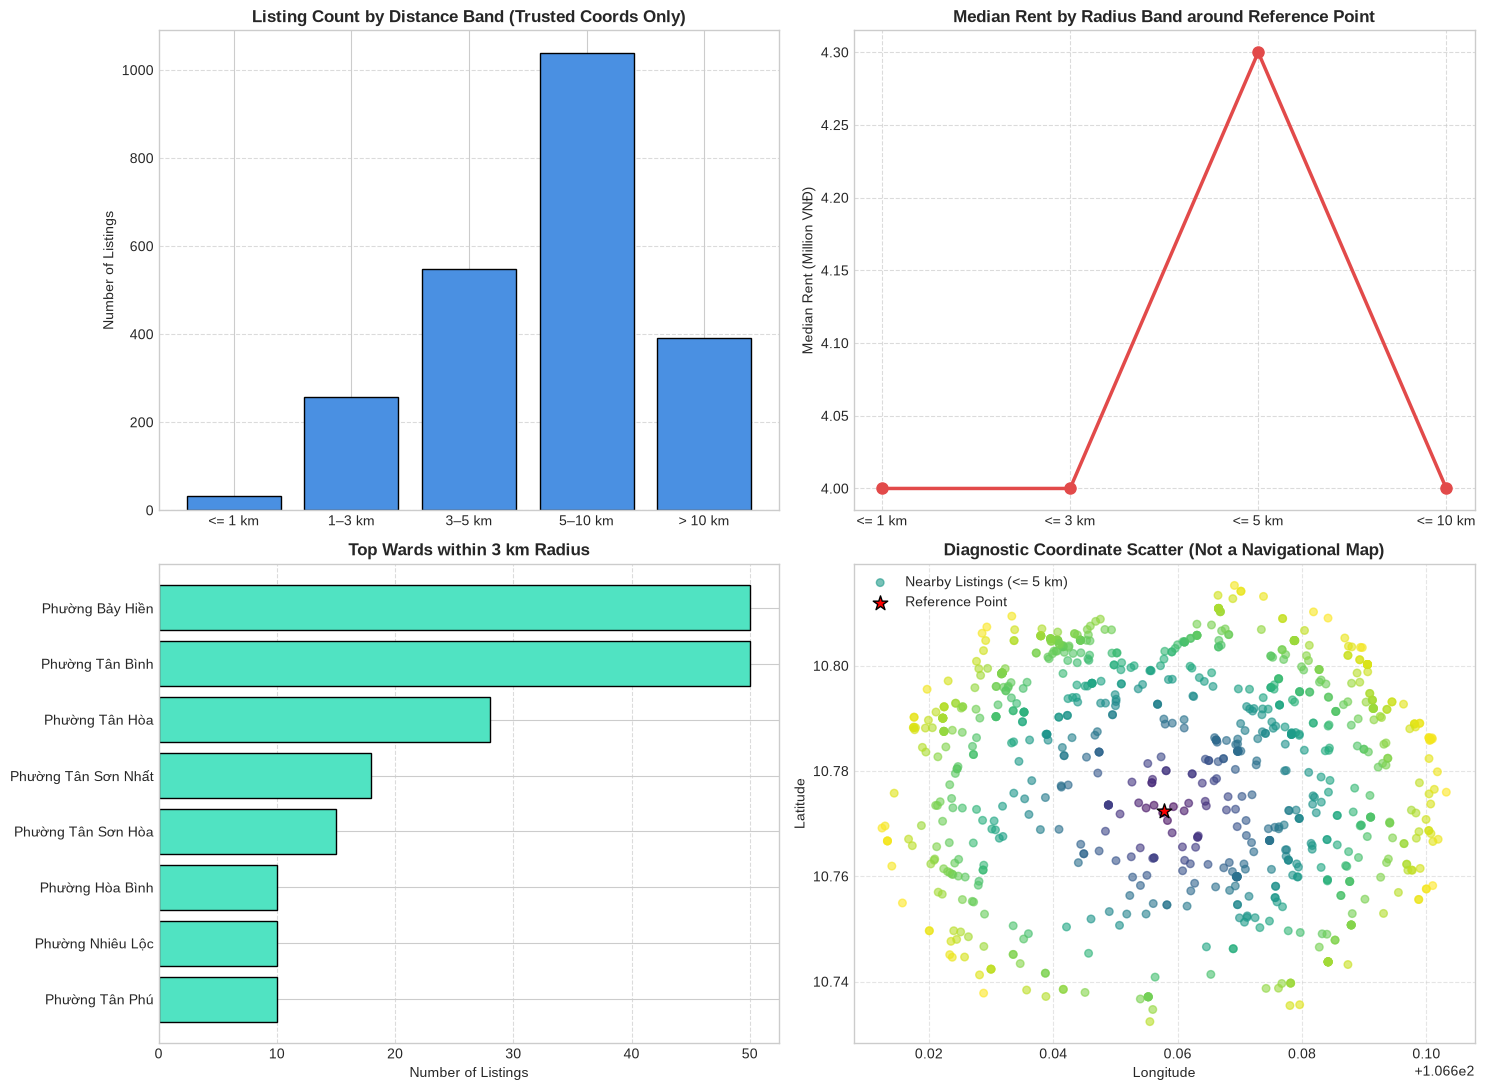

In [11]:
fig, axes = plt.subplots(2, 2, figsize=(15, 11))

# 1. Listing counts by distance band
band_counts = search_df['distance_band'].dropna().value_counts()[['<= 1 km', '1–3 km', '3–5 km', '5–10 km', '> 10 km']].dropna()
axes[0, 0].bar(band_counts.index, band_counts.values, color='#4A90E2', edgecolor='black')
axes[0, 0].set_title('Listing Count by Distance Band (Trusted Coords Only)', fontsize=12, fontweight='bold')
axes[0, 0].set_ylabel('Number of Listings')
axes[0, 0].grid(axis='y', linestyle='--', alpha=0.7)

# 2. Median rent by radius band
valid_market = market_summary.dropna(subset=['Median Rent (VNĐ)'])
axes[0, 1].plot(valid_market['Radius Band'], valid_market['Median Rent (VNĐ)'] / 1e6, marker='o', color='#E24A4A', linewidth=2.5, markersize=8)
axes[0, 1].set_title('Median Rent by Radius Band around Reference Point', fontsize=12, fontweight='bold')
axes[0, 1].set_ylabel('Median Rent (Million VNĐ)')
axes[0, 1].grid(True, linestyle='--', alpha=0.7)

# 3. Top wards around reference point within 3 km
top_wards = search_df.loc[search_df['distance_km'].le(3.0), 'ward_current'].dropna().value_counts().head(8)
axes[1, 0].barh(top_wards.index[::-1], top_wards.values[::-1], color='#50E3C2', edgecolor='black')
axes[1, 0].set_title('Top Wards within 3 km Radius', fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel('Number of Listings')
axes[1, 0].grid(axis='x', linestyle='--', alpha=0.7)

# 4. Diagnostic Coordinate Scatter (Explicitly NOT a navigational map)
trusted_subset = search_df.loc[search_df['distance_km'].le(5.0)]
axes[1, 1].scatter(trusted_subset['map_longitude'], trusted_subset['map_latitude'], c=trusted_subset['distance_km'], cmap='viridis', alpha=0.6, s=30, label='Nearby Listings (<= 5 km)')
axes[1, 1].scatter(REFERENCE_LONGITUDE, REFERENCE_LATITUDE, c='red', s=120, marker='*', edgecolor='black', zorder=5, label='Reference Point')
axes[1, 1].set_title('Diagnostic Coordinate Scatter (Not a Navigational Map)', fontsize=12, fontweight='bold')
axes[1, 1].set_xlabel('Longitude')
axes[1, 1].set_ylabel('Latitude')
axes[1, 1].legend(loc='upper left')
axes[1, 1].grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

## 12. Data Quality Findings & Forensic Limitations

1. **True Coordinate Coverage Constraint:** Only **1.72%** (2,268 listings) of rental listings in Silver possess trustworthy, pinpoint coordinates.
2. **Hotspot False Pinning:** Over 10,500 listings (7.98%) share repeated coordinates with mutually conflicting street addresses (district centroids / default pins). RoomBeacon isolates these to prevent false radius matching.
3. **Mismatched Portal Metadata:** Even among trusted coordinate embeds, poster errors exist (e.g. ID `69388` describes Lê Thánh Tôn, Quận 1 but its coordinate was placed in Quận 10). The coordinate search status contract classifies these as `TRUSTED_BUT_ADMIN_MISMATCH` and deprioritizes them deterministically.
4. **Administrative Retrieval Superiority:** Ward-level coverage reaches **83.74%**, making administrative matching (Same Ward / Same District) the primary reliable discovery mechanism for users today.


## 13. Product Readiness & Analytical Artifacts

In [12]:
readiness = evaluate_product_readiness(coverage_audit)
display(Markdown(f'''
### Current Location Retrieval Readiness: `{readiness['verdict']}`

{readiness['interpretation']}
'''))

# Persist analytical artifacts strictly to data/analysis/nearby_search/
ARTIFACT_DIR = PROJECT_ROOT / 'data' / 'analysis' / 'nearby_search'
ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)

coverage_audit.to_csv(ARTIFACT_DIR / 'location_quality_summary.csv', index=False)
funnel_df.to_csv(ARTIFACT_DIR / 'search_coverage_funnel.csv', index=False)
market_summary.to_csv(ARTIFACT_DIR / 'radius_market_summary.csv', index=False)
exact_results.to_csv(ARTIFACT_DIR / 'nearby_search_exact_results.csv', index=False)
same_ward_results.to_csv(ARTIFACT_DIR / 'same_ward_fallback_results.csv', index=False)
same_district_results.to_csv(ARTIFACT_DIR / 'same_district_fallback_results.csv', index=False)

metadata = {
    "generated_at": datetime.now(timezone.utc).astimezone().isoformat(),
    "reference_location": ref_contract,
    "price_display_policy": PRICE_DISPLAY_POLICY,
    "search_parameters": {
        "radius_km": SEARCH_RADIUS_KM,
        "max_results": MAX_RESULTS,
        "min_price": MIN_PRICE,
        "max_price": MAX_PRICE,
        "min_area": MIN_AREA,
        "max_area": MAX_AREA,
    },
    "taxonomy_counts": taxonomy_counts.set_index('Search Location Taxonomy State')['Listing Count'].to_dict(),
    "coordinate_search_quality": coord_quality.set_index('Coordinate Search Quality Status')['Listing Count'].to_dict(),
    "results_count": {
        "exact_distance_matches": len(exact_results),
        "same_ward_matches": len(same_ward_results),
        "same_district_matches": len(same_district_results),
    },
    "readiness": readiness,
}
(ARTIFACT_DIR / 'search_run_metadata.json').write_text(json.dumps(metadata, indent=2, ensure_ascii=False), encoding='utf-8')

display(Markdown(f'**Saved 6 analytical artifacts and run metadata to `{ARTIFACT_DIR}`.**'))
display(Markdown('**Notebook 05 execution complete.**'))


### Current Location Retrieval Readiness: `ADMIN_FALLBACK_READY`

RoomBeacon trusted coordinate coverage is currently limited (1.7%), while administrative ward coverage is substantial (83.7%). The platform reliably supports administrative location discovery (Same-Ward / Same-District), with exact radius retrieval operating as a high-precision but low-coverage prototype tier.


**Saved 6 analytical artifacts and run metadata to `/data/projects/roombeacon/source/roombeacon-system/data/analysis/nearby_search`.**

**Notebook 05 execution complete.**